# 05 — Model Comparison: DDPM vs Rectified Flow

Side-by-side evaluation of all trained generative models on the same real validation set.

**Requires** (run before this notebook):
- `02_clustering.ipynb` — produces `clusters.csv`
- `03_diffusion_training.ipynb` (full GPU run) — produces `best_model.pkl`
- `03b_rectified_flow_training.ipynb` (full GPU run) — produces `rf_best_model.pkl`

**Outputs**:
- `results/comparison/comparison_metrics.csv` — summary table (models × conditions × metrics)
- `results/comparison/figures/` — per-condition plots saved as PNG

**Metrics compared**: Discriminative accuracy · CRPS · ACF L2 · Marginal Wasserstein

In [1]:
# -- Environment bootstrap ----------------------------------------------------
import importlib.util
import os
import shutil
import subprocess
import sys
import tarfile
import tempfile
import urllib.request
import zipfile
from dataclasses import dataclass
from pathlib import Path


def _is_colab():
    return importlib.util.find_spec('google.colab') is not None


def find_or_bootstrap_repo_root():
    candidates = [
        Path('/home/nicola/Desktop/Supsi/tesina'),
        Path.cwd().resolve(),
        Path('/content/tesina'),
        Path('/tmp/vscode-colab/tesina'),
    ]
    for base in candidates:
        for candidate in [base, *base.parents]:
            if (candidate / 'src').exists() and (candidate / 'data').exists():
                return candidate

    if _is_colab():
        runtime_dir = Path('/content')
        repo_dir = runtime_dir / 'tesina'
    else:
        runtime_dir = Path(tempfile.gettempdir()) / 'vscode-colab'
        repo_dir = runtime_dir / 'tesina'

    archive_path = runtime_dir / 'tesina.zip'
    extract_dir = runtime_dir / 'tesina-master'
    repo_url = 'https://github.com/ncapac/tesina.git'
    archive_url = 'https://codeload.github.com/ncapac/tesina/zip/refs/heads/master'
    runtime_dir.mkdir(parents=True, exist_ok=True)
    if repo_dir.exists() and not (repo_dir / 'src').exists():
        shutil.rmtree(repo_dir)
    if not repo_dir.exists():
        try:
            result = subprocess.run(
                ['git', 'clone', '--depth', '1', repo_url, str(repo_dir)],
                capture_output=True, text=True,
            )
            if result.returncode != 0:
                raise RuntimeError(result.stderr)
        except Exception:
            if archive_path.exists():
                archive_path.unlink()
            if extract_dir.exists():
                shutil.rmtree(extract_dir)
            urllib.request.urlretrieve(archive_url, archive_path)
            with zipfile.ZipFile(archive_path, 'r') as z:
                z.extractall(runtime_dir)
            if repo_dir.exists():
                shutil.rmtree(repo_dir)
            shutil.move(str(extract_dir), str(repo_dir))
    if (repo_dir / 'src').exists() and (repo_dir / 'data').exists():
        return repo_dir
    raise RuntimeError('Could not locate or bootstrap the tesina project root.')


if 'JAX_PLATFORMS' not in os.environ:
    os.environ['JAX_PLATFORMS'] = 'cpu'
    print('Notebook 05 defaults to JAX_PLATFORMS=cpu. Set JAX_PLATFORMS before running if you want GPU.')

REPO_ROOT = find_or_bootstrap_repo_root()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from src.data.loader import load_raw, compute_stats, normalize
from src.data.dataset import make_windows, train_val_split
from src.models.diffusion import DiffusionProcess
from src.models.rectified_flow import RectifiedFlowProcess
from src.evaluation.metrics import (
    compare_models, marginal_wasserstein,
    acf_compare, crps_score, discriminative_score,
)

try:
    from src.runtime_paths import (
        find_latest_export_bundle,
        prepare_artifact_dirs,
        restore_latest_export_bundle,
    )
except ModuleNotFoundError:
    @dataclass(frozen=True)
    class _ArtifactPaths:
        repo_root: Path
        data_dir: Path
        checkpoints_dir: Path
        results_root: Path
        run_results_dir: Path

    def prepare_artifact_dirs(repo_root: str | Path, experiment: str | None = None) -> _ArtifactPaths:
        root = Path(repo_root).expanduser().resolve()
        data_dir = root / 'data'
        checkpoints_dir = root / 'checkpoints'
        results_root = root / 'results'
        run_results_dir = results_root if not experiment else results_root / experiment
        for directory in (checkpoints_dir, results_root, run_results_dir):
            directory.mkdir(parents=True, exist_ok=True)
        return _ArtifactPaths(
            repo_root=root,
            data_dir=data_dir,
            checkpoints_dir=checkpoints_dir,
            results_root=results_root,
            run_results_dir=run_results_dir,
        )

    def find_latest_export_bundle(repo_root: str | Path, prefix: str | None = None) -> Path | None:
        root = Path(repo_root).expanduser().resolve()
        exports_dir = root / 'results' / 'exports'
        if not exports_dir.exists():
            return None
        pattern = '*.tar.gz' if prefix is None else f'{prefix}*.tar.gz'
        bundles = sorted(exports_dir.glob(pattern))
        if not bundles:
            return None
        return bundles[-1].resolve()

    def _is_within_directory(parent: Path, child: Path) -> bool:
        try:
            child.relative_to(parent)
            return True
        except ValueError:
            return False

    def restore_export_bundle(
        archive_path: str | Path,
        repo_root: str | Path,
        *,
        overwrite: bool = True,
    ) -> list[Path]:
        root = Path(repo_root).expanduser().resolve()
        archive = Path(archive_path).expanduser().resolve()
        if not archive.exists():
            raise FileNotFoundError(f'Artifact bundle not found: {archive}')

        prepare_artifact_dirs(root)
        restored_paths = []
        with tarfile.open(archive, 'r:gz') as tar:
            for member in tar.getmembers():
                member_path = Path(member.name)
                if member_path.is_absolute():
                    raise ValueError(f'Archive contains absolute path: {member.name}')

                destination = (root / member_path).resolve()
                if not _is_within_directory(root, destination):
                    raise ValueError(f'Archive member escapes repo root: {member.name}')

                if member.isdir():
                    destination.mkdir(parents=True, exist_ok=True)
                    continue

                destination.parent.mkdir(parents=True, exist_ok=True)
                if destination.exists() and not overwrite:
                    continue

                extracted = tar.extractfile(member)
                if extracted is None:
                    continue

                with extracted, open(destination, 'wb') as output_file:
                    shutil.copyfileobj(extracted, output_file)
                restored_paths.append(destination)

        return restored_paths

    def restore_latest_export_bundle(
        repo_root: str | Path,
        prefix: str | None = None,
        *,
        overwrite: bool = True,
    ) -> tuple[Path, list[Path]] | None:
        latest_bundle = find_latest_export_bundle(repo_root, prefix=prefix)
        if latest_bundle is None:
            return None
        restored_paths = restore_export_bundle(latest_bundle, repo_root, overwrite=overwrite)
        return latest_bundle, restored_paths

try:
    from src.evaluation.metrics import sample_condition_batch
except ImportError:
    def sample_condition_batch(condition_rows: np.ndarray, n_samples: int, seed: int | None = None) -> np.ndarray:
        rows = np.asarray(condition_rows, dtype=np.int32)
        if rows.ndim != 2 or rows.shape[1] != 4:
            raise ValueError(f'Expected conditioning array of shape (N, 4); got {rows.shape}')
        if len(rows) == 0:
            raise ValueError('Cannot sample from an empty conditioning array')
        rng = np.random.default_rng(seed)
        replace = len(rows) < n_samples
        indices = rng.choice(len(rows), size=n_samples, replace=replace)
        return rows[indices].astype(np.int32, copy=False)

ARTIFACTS = prepare_artifact_dirs(REPO_ROOT, experiment='comparison')
DATA_DIR = ARTIFACTS.data_dir
CHECKPOINT_DIR = ARTIFACTS.checkpoints_dir
RESULTS_DIR = ARTIFACTS.run_results_dir
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DDPM_EXPORT_PREFIX = 'ddpm_baseline_'
RF_EXPORT_PREFIX = 'rf_baseline_'

plt.rcParams['figure.dpi'] = 110
print('Project root :', REPO_ROOT)
print('Checkpoints  :', CHECKPOINT_DIR)
print('Results dir  :', RESULTS_DIR)
print('Figures dir  :', FIGURES_DIR)
print('JAX devices  :', jax.devices())
latest_ddpm_bundle = find_latest_export_bundle(REPO_ROOT, prefix=DDPM_EXPORT_PREFIX)
latest_rf_bundle = find_latest_export_bundle(REPO_ROOT, prefix=RF_EXPORT_PREFIX)
print('Latest DDPM bundle:', latest_ddpm_bundle if latest_ddpm_bundle is not None else 'none found under results/exports')
print('Latest RF bundle  :', latest_rf_bundle if latest_rf_bundle is not None else 'none found under results/exports')

Notebook 05 defaults to JAX_PLATFORMS=cpu. Set JAX_PLATFORMS before running if you want GPU.
Project root : /content/tesina
Checkpoints  : /content/tesina/checkpoints
Results dir  : /content/tesina/results/comparison
Figures dir  : /content/tesina/results/comparison/figures
JAX devices  : [CpuDevice(id=0)]
Latest DDPM bundle: /content/tesina/results/exports/ddpm_baseline_20260408T133417Z.tar.gz
Latest RF bundle  : /content/tesina/results/exports/rf_baseline_20260408T153645Z.tar.gz


## 1. Load data and checkpoints

If a local DDPM or RF checkpoint is missing but a downloaded `*_baseline_*.tar.gz` bundle exists under `results/exports/`, the next checkpoint-loading cell will restore it automatically before unpickling the models.

In [2]:
# ── Data ─────────────────────────────────────────────────────────────────────
df = load_raw(DATA_DIR / 'power.pk')
clusters_df    = pd.read_csv(DATA_DIR / 'clusters.csv')
cluster_labels = clusters_df['cluster_id'].values
N_CLUSTERS     = int(cluster_labels.max()) + 1

timestamps = df.index if isinstance(df.index, pd.DatetimeIndex) else None
stats      = compute_stats(df, cluster_labels)
df_norm    = normalize(df, stats, cluster_labels)

xs, cs, mid = make_windows(df_norm, cluster_labels, timestamps)
_, _, x_val, c_val = train_val_split(xs, cs, mid, n_meters=df.shape[1])
print(f'Val set: {x_val.shape[0]} windows')

print('\nVal windows per condition:')
for cid in range(N_CLUSTERS):
    for dt, dn in [(0, 'weekday'), (1, 'weekend')]:
        n = ((c_val[:, 0] == cid) & (c_val[:, 1] == dt)).sum()
        print(f'  cluster{cid}_{dn}: {n}')

Val set: 52608 windows

Val windows per condition:
  cluster0_weekday: 21924
  cluster0_weekend: 8764
  cluster1_weekday: 3915
  cluster1_weekend: 1565
  cluster2_weekday: 11745
  cluster2_weekend: 4695


In [3]:
# -- Load checkpoints ---------------------------------------------------------
import pickle

DDPM_CKPT = CHECKPOINT_DIR / 'best_model.pkl'
RF_CKPT   = CHECKPOINT_DIR / 'rf_best_model.pkl'


def restore_checkpoint_if_needed(label, checkpoint_path, export_prefix):
    if checkpoint_path.exists():
        return None

    latest_bundle = find_latest_export_bundle(REPO_ROOT, prefix=export_prefix)
    if latest_bundle is None:
        return None

    restored = restore_latest_export_bundle(
        REPO_ROOT,
        prefix=export_prefix,
        overwrite=True,
    )
    if restored is None:
        return None

    bundle_path, restored_paths = restored
    print(f'Restored {len(restored_paths)} file(s) for {label} from {bundle_path}.')
    return bundle_path


restored_ddpm_bundle = restore_checkpoint_if_needed('DDPM', DDPM_CKPT, DDPM_EXPORT_PREFIX)
restored_rf_bundle = restore_checkpoint_if_needed('RF', RF_CKPT, RF_EXPORT_PREFIX)

missing_paths = [p for p in [DDPM_CKPT, RF_CKPT] if not p.exists()]
if missing_paths:
    missing_str = '\n'.join(f'  - {path}' for path in missing_paths)
    raise FileNotFoundError(
        'Missing checkpoint(s):\n'
        f'{missing_str}\n'
        'If you exported artifacts from Colab, place the downloaded archive(s) under results/exports/ and rerun this cell.'
    )

with open(DDPM_CKPT, 'rb') as f:
    ddpm_ckpt = pickle.load(f)
ddpm_model = ddpm_ckpt['model']
print(f'DDPM checkpoint loaded  (step {ddpm_ckpt["step"]})')
if restored_ddpm_bundle is not None:
    print(f'  restored from bundle -> {restored_ddpm_bundle}')

with open(RF_CKPT, 'rb') as f:
    rf_ckpt = pickle.load(f)
rf_model = rf_ckpt['model']
print(f'RF   checkpoint loaded  (step {rf_ckpt["step"]})')
if restored_rf_bundle is not None:
    print(f'  restored from bundle -> {restored_rf_bundle}')

# -- Instantiate processes ----------------------------------------------------
diffusion = DiffusionProcess(T=1000, freq_loss_weight=0.05)
rf_proc   = RectifiedFlowProcess(freq_loss_weight=0.05)

DDPM checkpoint loaded  (step 56064)
RF   checkpoint loaded  (step 233600)


## 2. Build generator functions

Each generator accepts `(c_batch: np.ndarray, seed: int) -> np.ndarray (N, L)`.
The `compare_models()` framework calls these for every condition.

In [4]:
N_SAMPLES      = 200     # synthetic samples per condition per model
GUIDANCE_SCALE = 1.5
N_DDIM_STEPS   = 50


def make_ddpm_generator(model, diff):
    def generate(c_batch, seed):
        key = jax.random.PRNGKey(int(seed))
        c   = jnp.array(c_batch, dtype=jnp.int32)
        return diff.ddim_sample(
            model, c,
            seq_len=24, batch_size=len(c_batch),
            key=key, n_steps=N_DDIM_STEPS, guidance_scale=GUIDANCE_SCALE,
        )
    return generate


def make_rf_generator(model, rf):
    def generate(c_batch, seed):
        key = jax.random.PRNGKey(int(seed))
        c   = jnp.array(c_batch, dtype=jnp.int32)
        return rf.sample(
            model, c,
            seq_len=24, batch_size=len(c_batch),
            key=key, n_steps=N_DDIM_STEPS, guidance_scale=GUIDANCE_SCALE,
        )
    return generate


models_dict = {
    'DDPM': make_ddpm_generator(ddpm_model, diffusion),
    'RF':   make_rf_generator(rf_model, rf_proc),
}

print(f'Generator functions ready: {list(models_dict.keys())}')
print(f'Samples per condition: {N_SAMPLES}  |  Guidance scale: {GUIDANCE_SCALE}')

Generator functions ready: ['DDPM', 'RF']
Samples per condition: 200  |  Guidance scale: 1.5


## 3. Run comparison

In [5]:
summary_df, figs_dict = compare_models(
    models_dict        = models_dict,
    real_data          = x_val,
    conditions         = c_val,
    n_samples          = N_SAMPLES,
    guidance_scale     = GUIDANCE_SCALE,
    n_ddim_steps       = N_DDIM_STEPS,
    seed               = 0,
    show_figs          = False,  # set True to display per-condition figures inline
    verbose            = True,
)

print('\n── Summary ──')
print(summary_df.to_string(index=False))


── Model: DDPM ──
  cluster0_weekday ... disc=0.592  crps=0.1239  acf_l2=0.3144  wass=0.1975
  cluster0_weekend ... disc=0.692  crps=0.1530  acf_l2=0.3703  wass=0.2615
  cluster1_weekday ... disc=0.708  crps=0.0470  acf_l2=0.0720  wass=0.1076
  cluster1_weekend ... disc=0.775  crps=0.0684  acf_l2=0.1246  wass=0.1438
  cluster2_weekday ... disc=0.517  crps=0.2244  acf_l2=0.2430  wass=0.2637
  cluster2_weekend ... disc=0.525  crps=0.1881  acf_l2=0.2773  wass=0.1971

── Model: RF ──
  cluster0_weekday ... disc=0.692  crps=0.0955  acf_l2=0.3172  wass=0.0595
  cluster0_weekend ... disc=0.400  crps=0.0945  acf_l2=0.3596  wass=0.0436
  cluster1_weekday ... disc=0.642  crps=0.0410  acf_l2=0.1160  wass=0.1332
  cluster1_weekend ... disc=0.700  crps=0.0350  acf_l2=0.1144  wass=0.1291
  cluster2_weekday ... disc=0.683  crps=0.2546  acf_l2=0.3161  wass=0.2479
  cluster2_weekend ... disc=0.642  crps=0.2171  acf_l2=0.3924  wass=0.2141

── Summary ──
model  cluster day_type        condition  n_real 

## 4. Summary metric table

In [6]:
metric_cols = ['discriminative_acc', 'crps', 'acf_l2', 'wasserstein']

# Pivot: rows = condition, cols = (model, metric)
pivot = summary_df.pivot_table(
    index='condition', columns='model', values=metric_cols,
)
print('Comparison table:')
print(pivot.round(4).to_string())

# Save CSV
csv_path = RESULTS_DIR / 'comparison_metrics.csv'
summary_df.to_csv(csv_path, index=False)
print(f'\nSaved -> {csv_path}')

Comparison table:
                  acf_l2            crps         discriminative_acc         wasserstein        
model               DDPM      RF    DDPM      RF               DDPM      RF        DDPM      RF
condition                                                                                      
cluster0_weekday  0.3144  0.3172  0.1239  0.0955             0.5917  0.6917      0.1975  0.0595
cluster0_weekend  0.3703  0.3596  0.1530  0.0945             0.6917  0.4000      0.2615  0.0436
cluster1_weekday  0.0720  0.1160  0.0470  0.0410             0.7083  0.6417      0.1076  0.1332
cluster1_weekend  0.1246  0.1144  0.0684  0.0350             0.7750  0.7000      0.1438  0.1291
cluster2_weekday  0.2430  0.3161  0.2244  0.2546             0.5167  0.6833      0.2637  0.2479
cluster2_weekend  0.2773  0.3924  0.1881  0.2171             0.5250  0.6417      0.1971  0.2141

Saved -> /content/tesina/results/comparison/comparison_metrics.csv


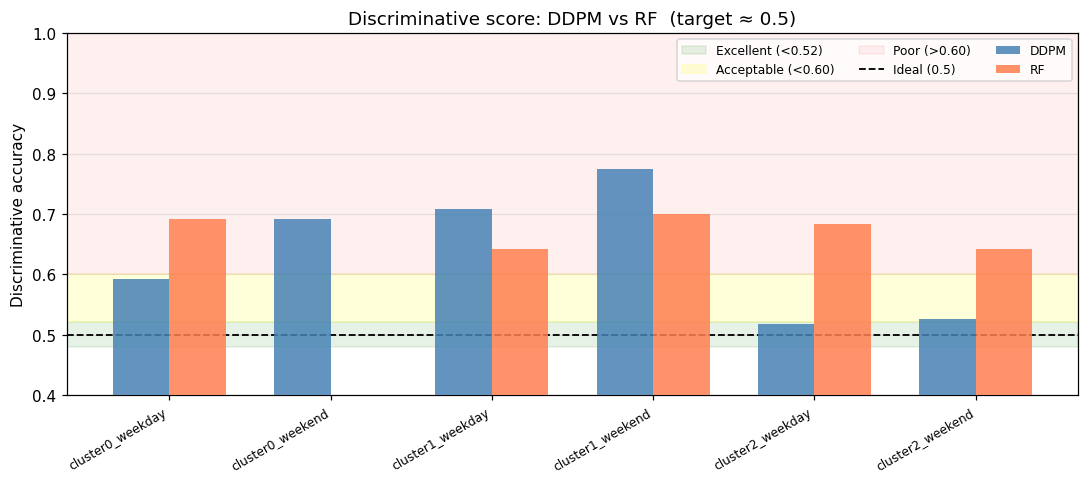

In [7]:
# ── Bar chart: discriminative accuracy per condition per model ────────────────
conditions_ordered = sorted(summary_df['condition'].unique())
n_cond = len(conditions_ordered)
x_pos  = np.arange(n_cond)
width  = 0.35
colors_m = {'DDPM': 'steelblue', 'RF': 'coral'}

fig, ax = plt.subplots(figsize=(max(10, n_cond * 1.6), 4.5))
for i, model_name in enumerate(['DDPM', 'RF']):
    sub = summary_df[summary_df['model'] == model_name].set_index('condition')
    vals = [sub.loc[c, 'discriminative_acc'] if c in sub.index else float('nan')
            for c in conditions_ordered]
    ax.bar(x_pos + i * width - width/2, vals,
           width=width, label=model_name, color=colors_m[model_name], alpha=0.85, zorder=3)

# Quality bands
ax.axhspan(0.48, 0.52, color='green',  alpha=0.10, label='Excellent (<0.52)')
ax.axhspan(0.52, 0.60, color='yellow', alpha=0.15, label='Acceptable (<0.60)')
ax.axhspan(0.60, 1.00, color='red',    alpha=0.06, label='Poor (>0.60)')
ax.axhline(0.5,  color='black', ls='--', lw=1.2, label='Ideal (0.5)')

ax.set_xticks(x_pos); ax.set_xticklabels(conditions_ordered, rotation=30, ha='right', fontsize=8)
ax.set_ylim(0.4, 1.0); ax.set_ylabel('Discriminative accuracy')
ax.set_title('Discriminative score: DDPM vs RF  (target ≈ 0.5)')
ax.legend(ncol=3, fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.tight_layout(); plt.show()
fig.savefig(FIGURES_DIR / 'discriminative_comparison.png', dpi=150, bbox_inches='tight')

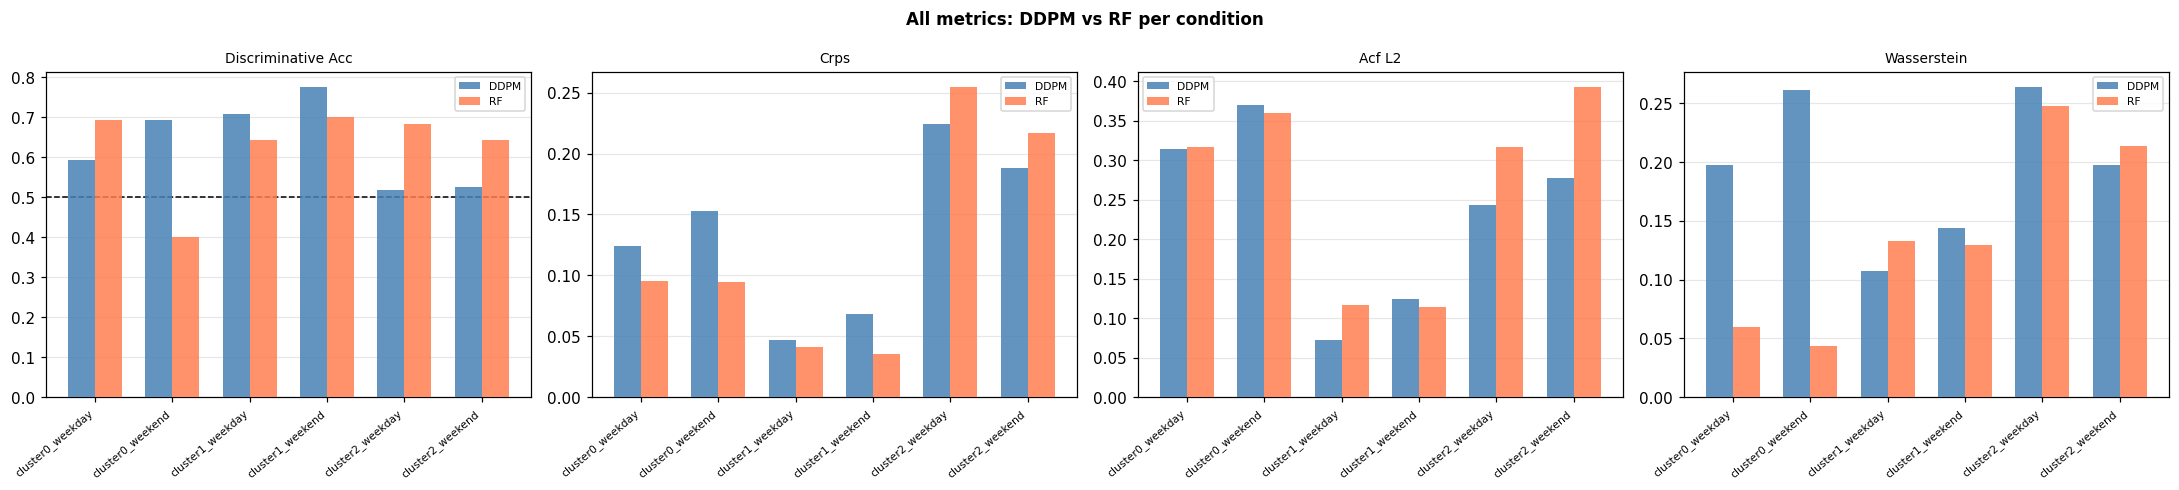

In [8]:
# ── Radar / grouped bar: all 4 metrics (normalised) ──────────────────────────
# Normalise each metric to [0,1] range across all values for easy visual comparison.
# For disc_acc, distance from 0.5 is the meaningful quantity.

fig, axes = plt.subplots(1, len(metric_cols), figsize=(5 * len(metric_cols), 4.5), sharey=False)
colors_m2 = ['steelblue', 'coral']

for ax, metric in zip(axes, metric_cols):
    for i, model_name in enumerate(['DDPM', 'RF']):
        sub = summary_df[summary_df['model'] == model_name].set_index('condition')
        vals = [float(sub.loc[c, metric]) if c in sub.index else float('nan')
                for c in conditions_ordered]
        ax.bar(x_pos + i * width - width/2, vals,
               width=width, label=model_name, color=colors_m2[i], alpha=0.85, zorder=3)
    if metric == 'discriminative_acc':
        ax.axhline(0.5, color='black', ls='--', lw=1.0)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(conditions_ordered, rotation=40, ha='right', fontsize=7)
    ax.set_title(metric.replace('_', ' ').title(), fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=7)

plt.suptitle('All metrics: DDPM vs RF per condition', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
fig.savefig(FIGURES_DIR / 'all_metrics_comparison.png', dpi=150, bbox_inches='tight')

## 5. Per-condition visual comparison

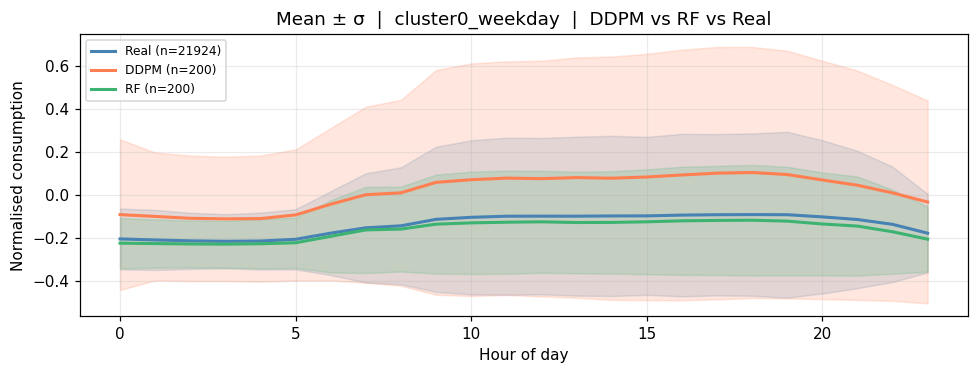

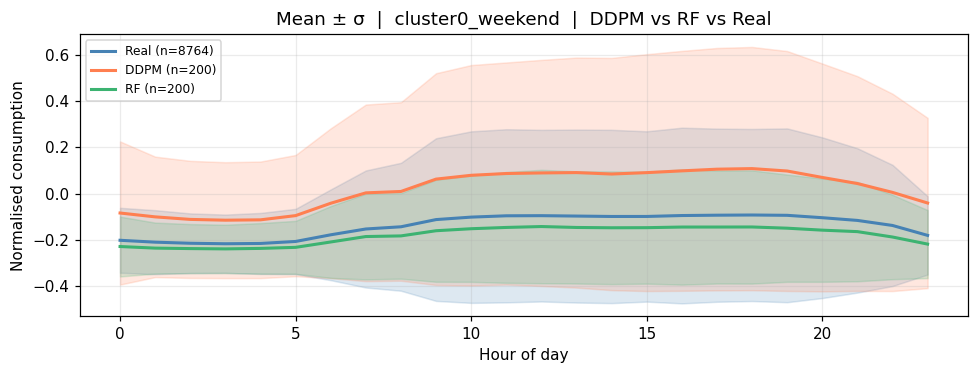

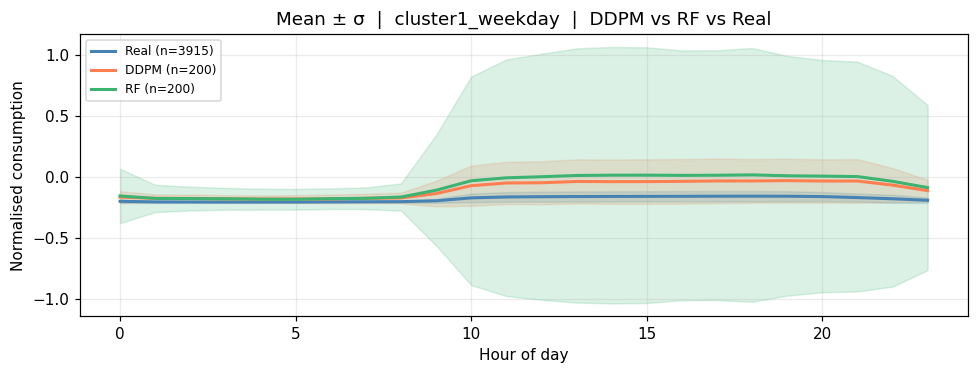

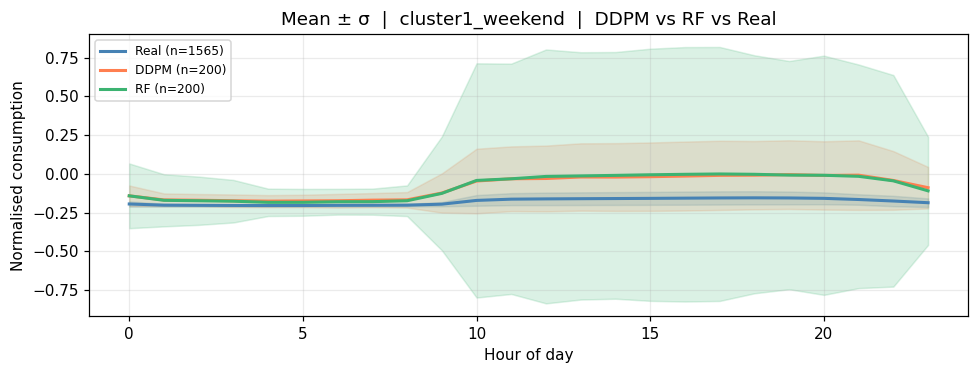

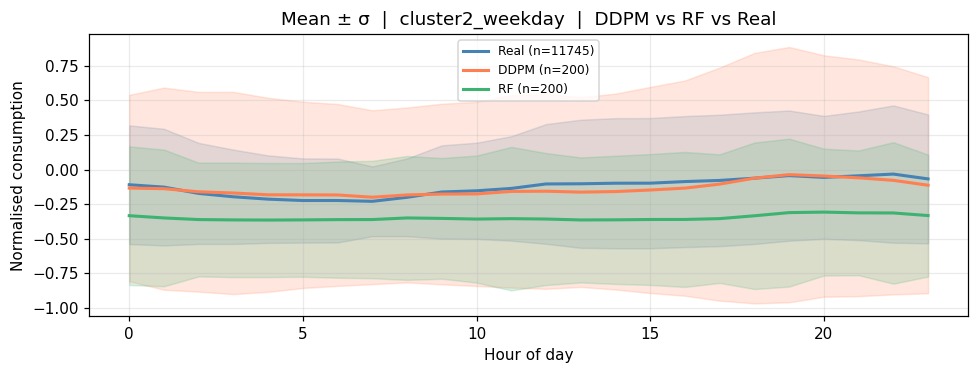

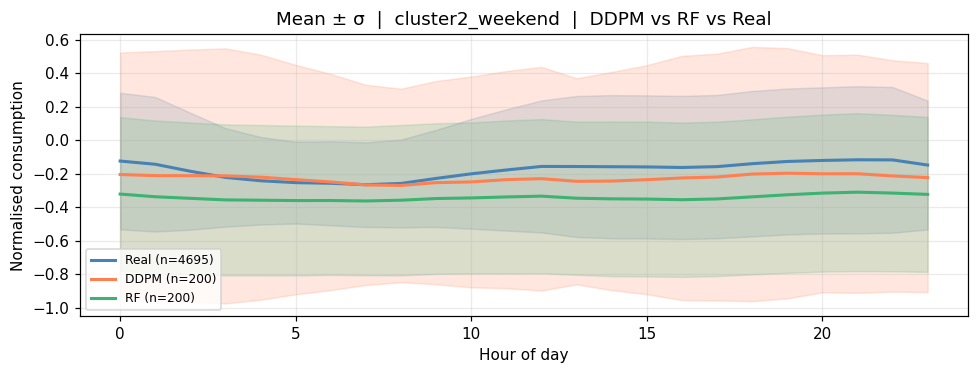

In [9]:
# ── Generate sample galleries for each condition ──────────────────────────────
# For each (cluster, day_type): side-by-side mean±σ profiles DDPM vs RF vs Real
# using the empirical month/day-of-week mixture from the real validation slice.

hours = np.arange(24)
rng_gallery = np.random.default_rng(0)

for cid in range(N_CLUSTERS):
    for dt, day_name in [(0, 'Weekday'), (1, 'Weekend')]:
        cond_label = f"cluster{cid}_{'weekday' if dt == 0 else 'weekend'}"

        mask_r = (c_val[:, 0] == cid) & (c_val[:, 1] == dt)
        real_cond = x_val[mask_r]
        cond_rows = c_val[mask_r]
        if len(real_cond) < 5:
            print(f'Skipping {cond_label}: only {len(real_cond)} real samples')
            continue

        c_batch_np = sample_condition_batch(
            cond_rows,
            n_samples=N_SAMPLES,
            seed=int(rng_gallery.integers(0, 2**31)),
        )
        c_batch = jnp.array(c_batch_np, dtype=jnp.int32)

        synth_ddpm = np.array(diffusion.ddim_sample(
            ddpm_model, c_batch, seq_len=24, batch_size=N_SAMPLES,
            key=jax.random.PRNGKey(cid * 10 + dt), n_steps=50, guidance_scale=GUIDANCE_SCALE,
        ))
        synth_rf = np.array(rf_proc.sample(
            rf_model, c_batch, seq_len=24, batch_size=N_SAMPLES,
            key=jax.random.PRNGKey(cid * 10 + dt + 50), n_steps=50, guidance_scale=GUIDANCE_SCALE,
        ))

        fig, ax = plt.subplots(figsize=(9, 3.5))
        for arr, name, col in [
            (real_cond, 'Real',  'steelblue'),
            (synth_ddpm, 'DDPM', 'coral'),
            (synth_rf,   'RF',   'mediumseagreen'),
        ]:
            mu, s = arr.mean(0), arr.std(0)
            ax.fill_between(hours, mu - s, mu + s, alpha=0.18, color=col)
            ax.plot(hours, mu, color=col, lw=2, label=f'{name} (n={len(arr)})')

        ax.set_xlabel('Hour of day'); ax.set_ylabel('Normalised consumption')
        ax.set_title(f'Mean ± σ  |  {cond_label}  |  DDPM vs RF vs Real')
        ax.legend(fontsize=8); ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()
        fig.savefig(FIGURES_DIR / f'profile_{cond_label}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)

## 6. Training convergence comparison

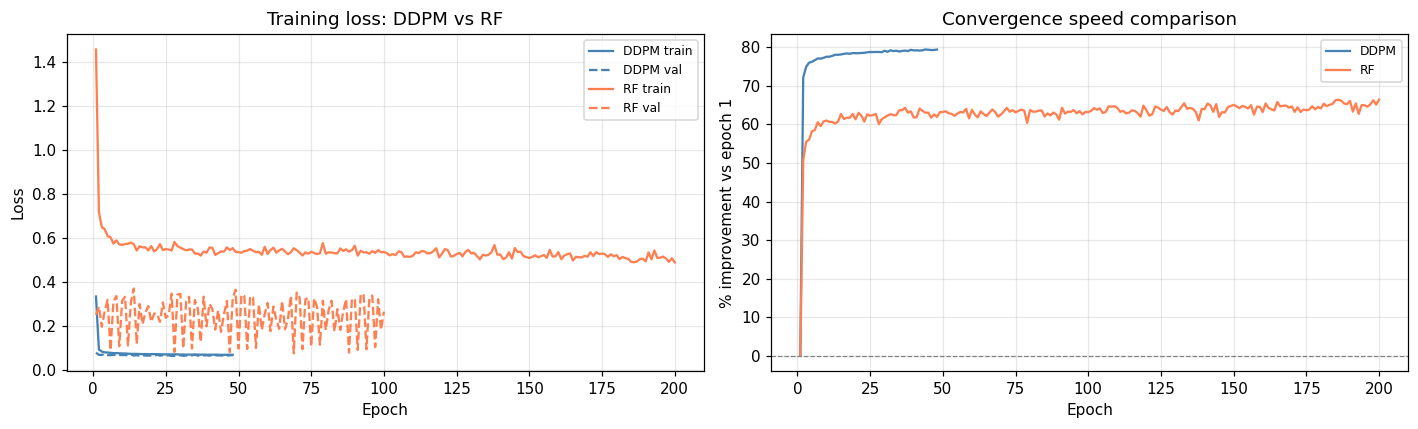

In [10]:
# ── Overlay DDPM and RF training loss curves ──────────────────────────────────
ddpm_tr = ddpm_ckpt.get('train_losses', [])
ddpm_va = ddpm_ckpt.get('val_losses',   [])
rf_tr   = rf_ckpt.get('train_losses',   [])
rf_va   = rf_ckpt.get('val_losses',     [])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for losses, name, col, ls in [
    (ddpm_tr, 'DDPM train', 'steelblue', '-'),
    (ddpm_va, 'DDPM val',   'steelblue', '--'),
    (rf_tr,   'RF train',   'coral',     '-'),
    (rf_va,   'RF val',     'coral',     '--'),
]:
    if losses:
        axes[0].plot(range(1, len(losses)+1), losses,
                     color=col, ls=ls, lw=1.5, label=name)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training loss: DDPM vs RF')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Relative improvement from epoch 1
for losses, name, col, ls in [
    (ddpm_tr, 'DDPM', 'steelblue', '-'),
    (rf_tr,   'RF',   'coral',     '-'),
]:
    if len(losses) > 1:
        rel = [(losses[0] - l) / losses[0] * 100 for l in losses]
        axes[1].plot(range(1, len(rel)+1), rel, color=col, ls=ls, lw=1.5, label=name)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('% improvement vs epoch 1')
axes[1].set_title('Convergence speed comparison')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='grey', ls='--', lw=0.8)

plt.tight_layout(); plt.show()
fig.savefig(FIGURES_DIR / 'convergence_comparison.png', dpi=150, bbox_inches='tight')

## 7. Ablation: CFG guidance scale

model  scale     disc     crps   acf_l2     wass
 DDPM    0.0 0.477778 0.102126 0.234439 0.110437
 DDPM    0.5 0.400000 0.097725 0.268003 0.082342
 DDPM    1.0 0.533333 0.106483 0.290280 0.121415
 DDPM    1.5 0.533333 0.104426 0.341080 0.135841
 DDPM    2.5 0.500000 0.117359 0.407068 0.150862
 DDPM    4.0 0.644444 0.144904 0.441003 0.237281
   RF    0.0 0.422222 0.093369 0.224299 0.041794
   RF    0.5 0.588889 0.095178 0.283200 0.052914
   RF    1.0 0.588889 0.093906 0.290823 0.042675
   RF    1.5 0.511111 0.094908 0.332547 0.041057
   RF    2.5 0.566667 0.094168 0.352913 0.038825
   RF    4.0 0.611111 0.095433 0.407679 0.054833


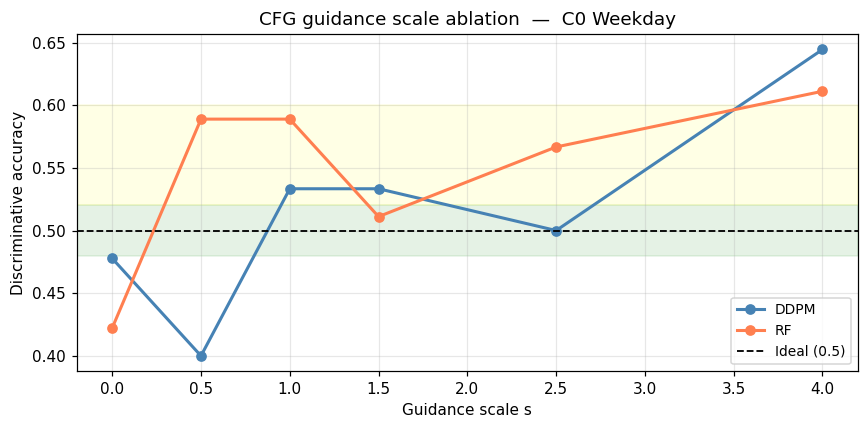

In [11]:
# ── Guidance scale sweep on Cluster 0 Weekday ────────────────────────────────
ABLATION_SCALES = [0.0, 0.5, 1.0, 1.5, 2.5, 4.0]
ABLATION_CID    = 0
ABLATION_DT     = 0     # weekday
ABLATION_N      = 150

mask_abl  = (c_val[:, 0] == ABLATION_CID) & (c_val[:, 1] == ABLATION_DT)
real_abl  = x_val[mask_abl]
c_abl_np  = np.array([[ABLATION_CID, ABLATION_DT, 5, 1]] * ABLATION_N, dtype=np.int32)

rows_abl = []
for model_name, generate_fn in models_dict.items():
    for scale in ABLATION_SCALES:
        # Temporarily build a generator with this specific scale
        c_jax = jnp.array(c_abl_np)
        key   = jax.random.PRNGKey(int(scale * 100))
        if model_name == 'DDPM':
            synth = np.array(diffusion.ddim_sample(
                ddpm_model, c_jax, seq_len=24, batch_size=ABLATION_N,
                key=key, n_steps=50, guidance_scale=scale,
            ))
        else:
            synth = np.array(rf_proc.sample(
                rf_model, c_jax, seq_len=24, batch_size=ABLATION_N,
                key=key, n_steps=50, guidance_scale=scale,
            ))
        disc = discriminative_score(real_abl, synth)
        crps = crps_score(real_abl, synth)
        acf  = acf_compare(real_abl, synth)
        wass = marginal_wasserstein(real_abl, synth)
        rows_abl.append({'model': model_name, 'scale': scale,
                         'disc': disc, 'crps': crps, 'acf_l2': acf, 'wass': wass})

abl_df = pd.DataFrame(rows_abl)
print(abl_df.to_string(index=False))

# ── Plot disc accuracy vs guidance scale ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for model_name, col in [('DDPM', 'steelblue'), ('RF', 'coral')]:
    sub = abl_df[abl_df['model'] == model_name]
    ax.plot(sub['scale'], sub['disc'], 'o-', color=col, lw=2, label=model_name)
ax.axhline(0.5, color='black', ls='--', lw=1.2, label='Ideal (0.5)')
ax.axhspan(0.48, 0.52, color='green',  alpha=0.10)
ax.axhspan(0.52, 0.60, color='yellow', alpha=0.10)
ax.set_xlabel('Guidance scale s'); ax.set_ylabel('Discriminative accuracy')
ax.set_title(f'CFG guidance scale ablation  —  C{ABLATION_CID} Weekday')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
fig.savefig(FIGURES_DIR / 'guidance_scale_ablation.png', dpi=150, bbox_inches='tight')

## 8. Conditioning ablation

How much does each conditioning feature contribute to sample quality?
Compare: cluster-only  vs  cluster+day_type  vs  full (cluster+day_type+month+dow).

  DDPM  full                  disc=0.567  wass=0.1335
  DDPM  no_dow_month          disc=0.489  wass=0.0655
  DDPM  cluster_only          disc=0.556  wass=0.0866
  DDPM  unconditional         disc=0.456  wass=0.2213
  RF    full                  disc=0.467  wass=0.0471
  RF    no_dow_month          disc=0.489  wass=0.0580
  RF    cluster_only          disc=0.500  wass=0.0579
  RF    unconditional         disc=0.522  wass=0.0777


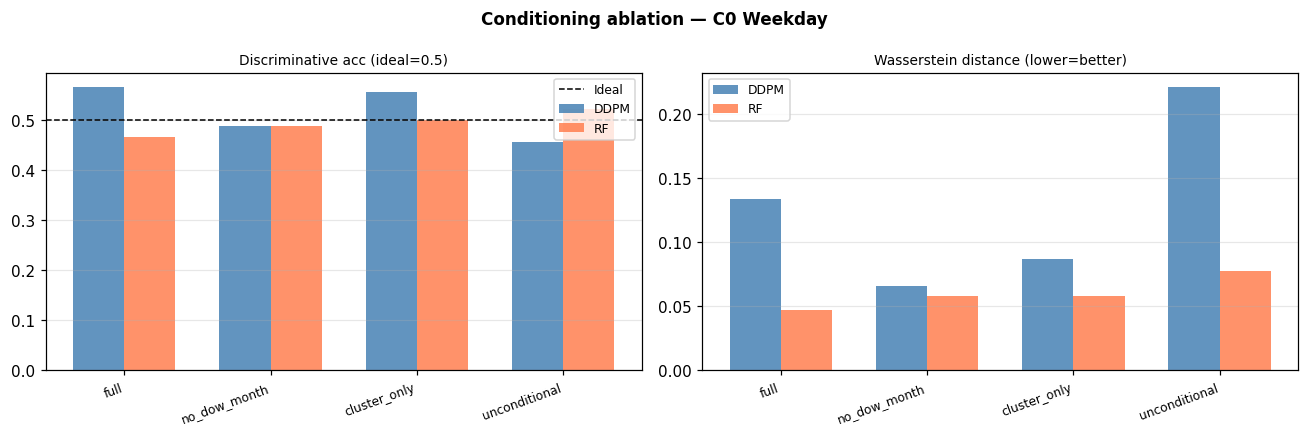

In [12]:
# ── Conditioning ablation on Cluster 0 Weekday ───────────────────────────────
# Achieved by zeroing out features in c_batch (setting to -1 = null token)
# Full:         [cid, dt, month, dow]
# No dow/month: [cid, dt, -1, -1]
# No day_type:  [cid, -1, -1, -1]
# Null (uncond):[−1, -1, -1, -1]

ablation_configs = {
    'full':               (ABLATION_CID, ABLATION_DT, 5, 1),
    'no_dow_month':       (ABLATION_CID, ABLATION_DT, -1, -1),
    'cluster_only':       (ABLATION_CID, -1, -1, -1),
    'unconditional':      (-1, -1, -1, -1),
}

rows_cond = []
for model_name, generate_fn in models_dict.items():
    for config_name, c_vals in ablation_configs.items():
        c_jax = jnp.array([list(c_vals)] * ABLATION_N, dtype=jnp.int32)
        key   = jax.random.PRNGKey(42)
        if model_name == 'DDPM':
            synth = np.array(diffusion.ddim_sample(
                ddpm_model, c_jax, seq_len=24, batch_size=ABLATION_N,
                key=key, n_steps=50, guidance_scale=GUIDANCE_SCALE,
            ))
        else:
            synth = np.array(rf_proc.sample(
                rf_model, c_jax, seq_len=24, batch_size=ABLATION_N,
                key=key, n_steps=50, guidance_scale=GUIDANCE_SCALE,
            ))
        disc = discriminative_score(real_abl, synth)
        wass = marginal_wasserstein(real_abl, synth)
        rows_cond.append({'model': model_name, 'conditioning': config_name,
                          'disc': disc, 'wasserstein': wass})
        print(f'  {model_name:4s}  {config_name:<20s}  disc={disc:.3f}  wass={wass:.4f}')

cond_df = pd.DataFrame(rows_cond)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
config_labels = list(ablation_configs.keys())
xpos = np.arange(len(config_labels))
width = 0.35
for i, (model_name, col) in enumerate([('DDPM', 'steelblue'), ('RF', 'coral')]):
    sub = cond_df[cond_df['model'] == model_name].set_index('conditioning')
    for ax_i, metric in [(0, 'disc'), (1, 'wasserstein')]:
        vals = [float(sub.loc[c, metric]) if c in sub.index else float('nan')
                for c in config_labels]
        axes[ax_i].bar(xpos + i * width - width/2, vals,
                       width=width, label=model_name, color=col, alpha=0.85)

for ax_i, (title, ideal_line) in enumerate([
    ('Discriminative acc (ideal=0.5)', 0.5),
    ('Wasserstein distance (lower=better)', None),
]):
    axes[ax_i].set_xticks(xpos)
    axes[ax_i].set_xticklabels(config_labels, rotation=20, ha='right', fontsize=8)
    axes[ax_i].set_title(title, fontsize=9)
    if ideal_line is not None:
        axes[ax_i].axhline(ideal_line, color='black', ls='--', lw=1.0, label='Ideal')
    axes[ax_i].legend(fontsize=8); axes[ax_i].grid(axis='y', alpha=0.3)

plt.suptitle('Conditioning ablation — C0 Weekday', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
fig.savefig(FIGURES_DIR / 'conditioning_ablation.png', dpi=150, bbox_inches='tight')

## 9. Final summary & thesis notes

In [14]:
print("=" * 65)
print("COMPARISON SUMMARY")
print("=" * 65)

for model_name in ['DDPM', 'RF']:
    sub = summary_df[summary_df['model'] == model_name]
    if sub.empty:
        continue
    print(f"\n-- {model_name} --")
    for _, row in sub.iterrows():
        offset  = abs(row['discriminative_acc'] - 0.5)
        quality = "excellent" if offset < 0.02 else ("good" if offset < 0.10 else
                  ("fair" if offset < 0.20 else "poor"))
        print(
            f"  {row['condition']:<35s}  "
            f"disc={row['discriminative_acc']:.3f} [{quality}]  "
            f"crps={row['crps']:.4f}  "
            f"acf={row['acf_l2']:.4f}  "
            f"wass={row['wasserstein']:.4f}"
        )

print("\n" + "-" * 65)
print("THESIS NOTE - Weekday/Weekend separation:")
print("  Day-type signal is only ~1.4% in this dataset (see 01_eda §4b).")
print("  Expect near-identical weekday vs weekend metrics for both models.")
print("  This is the expected behaviour - not a model failure.")
print()
print("THESIS NOTE - DDPM vs RF comparison framing:")
print("  RF trains on velocity matching (continuous t) vs DDPM on noise")
print("  prediction (discrete t). With L=24 (very short sequences) and a")
print("  shared Transformer backbone, differences are expected to be small.")
print("  Key comparison axes: convergence speed, sample diversity (sigma),")
print("  and sharpness of daily peak (ACF + per-timestep sigma).")
print()
print(f"All figures saved to: {FIGURES_DIR}")
print(f"Metrics CSV saved to: {RESULTS_DIR / 'comparison_metrics.csv'}")

COMPARISON SUMMARY

-- DDPM --
  cluster0_weekday                     disc=0.592 [good]  crps=0.1239  acf=0.3144  wass=0.1975
  cluster0_weekend                     disc=0.692 [fair]  crps=0.1530  acf=0.3703  wass=0.2615
  cluster1_weekday                     disc=0.708 [poor]  crps=0.0470  acf=0.0720  wass=0.1076
  cluster1_weekend                     disc=0.775 [poor]  crps=0.0684  acf=0.1246  wass=0.1438
  cluster2_weekday                     disc=0.517 [excellent]  crps=0.2244  acf=0.2430  wass=0.2637
  cluster2_weekend                     disc=0.525 [good]  crps=0.1881  acf=0.2773  wass=0.1971

-- RF --
  cluster0_weekday                     disc=0.692 [fair]  crps=0.0955  acf=0.3172  wass=0.0595
  cluster0_weekend                     disc=0.400 [good]  crps=0.0945  acf=0.3596  wass=0.0436
  cluster1_weekday                     disc=0.642 [fair]  crps=0.0410  acf=0.1160  wass=0.1332
  cluster1_weekend                     disc=0.700 [fair]  crps=0.0350  acf=0.1144  wass=0.1291
  cl